In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("berlin_jobs.csv")
df.head()

,job_id,job_title,company,sector,company_type,city,experience_level,salary_EUR,skills_required,german_required,visa_sponsorship,remote_policy,ai_tools_mentioned,date_posted
0,JOB1000,SQL Data Analyst,GreenData GmbH,E-Commerce,Corporate,Berlin,Senior (5+),65648.0,"Python, SQL, Power BI, A/B Testing",True,True,Remote,True,2024-11-28
1,JOB1001,Data Analyst,BMW Berlin,Automotive,Corporate,Berlin,Senior (5+),79856.0,"Tableau, Excel, Power BI, R, SQL, NumPy, Machi...",True,False,Remote,False,2024-01-23
2,JOB1002,Data Analyst,Bayer Berlin,Media,Corporate,Berlin,Senior (5+),77054.0,"SQL, Python, Data Visualization, Power BI, Tab...",True,False,On-site,False,2024-03-24
3,JOB1003,SQL Data Analyst,SAP Berlin,Automotive,Startup,Berlin,Mid (2-5),57641.0,"Statistics, Machine Learning, Tableau, Data Vi...",True,False,On-site,True,2024-01-17
4,JOB1004,Junior BI Analyst,AUTO1 Group,Logistics,Corporate,Hybrid (Berlin),Mid (2-5),NaN,"Statistics, Machine Learning, Data Visualizati...",False,False,On-site,False,2024-05-14


In [3]:
df.shape

(500, 14)

In [4]:
df.columns

Index(['job_id', 'job_title', 'company', 'sector', 'company_type', 'city',
       'experience_level', 'salary_EUR', 'skills_required', 'german_required',
       'visa_sponsorship', 'remote_policy', 'ai_tools_mentioned',
       'date_posted'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_id              500 non-null    str    
 1   job_title           500 non-null    str    
 2   company             500 non-null    str    
 3   sector              500 non-null    str    
 4   company_type        500 non-null    str    
 5   city                500 non-null    str    
 6   experience_level    476 non-null    str    
 7   salary_EUR          466 non-null    float64
 8   skills_required     500 non-null    str    
 9   german_required     500 non-null    bool   
 10  visa_sponsorship    500 non-null    bool   
 11  remote_policy       500 non-null    str    
 12  ai_tools_mentioned  500 non-null    bool   
 13  date_posted         500 non-null    str    
dtypes: bool(3), float64(1), str(10)
memory usage: 44.6 KB


In [6]:
df.isnull() .sum()

job_id                 0
job_title              0
company                0
sector                 0
company_type           0
city                   0
experience_level      24
salary_EUR            34
skills_required        0
german_required        0
visa_sponsorship       0
remote_policy          0
ai_tools_mentioned     0
date_posted            0
dtype: int64

In [7]:
df["salary_EUR"].describe()

count       466.000000
mean      84673.690987
std      131819.594786
min       32126.000000
25%       44476.750000
50%       57774.000000
75%       70767.750000
max      987684.000000
Name: salary_EUR, dtype: float64

In [8]:
df.loc[df["salary_EUR"]>2000000 ,"salary_EUR"] = None

median_salary = df["salary_EUR"].median()
df["salary_EUR"] = df["salary_EUR"].fillna(median_salary)

print(f" median salary is : {median_salary:,.0f} ERU")
print(f" Remaining blank values: {df['salary_EUR'].isnull().sum()}")

 median salary is : 57,774 ERU
 Remaining blank values: 0


In [9]:
df["experience_level"] = df["experience_level"].fillna("unknown")
print (df["experience_level"].value_counts())

experience_level
Mid (2-5)       168
Senior (5+)     157
Junior (0-2)    151
unknown          24
Name: count, dtype: int64


In [10]:
print("Empty values after cleaning:")
print(df.isnull().sum())
print(f"\nTotal number of rows:{len(df)}")

Empty values after cleaning:
job_id                0
job_title             0
company               0
sector                0
company_type          0
city                  0
experience_level      0
salary_EUR            0
skills_required       0
german_required       0
visa_sponsorship      0
remote_policy         0
ai_tools_mentioned    0
date_posted           0
dtype: int64

Total number of rows:500


In [11]:
df.to_csv("berlin_job_clean.csv", index=False)
print("The file is save")

The file is save


In [12]:
print(df["company_type"].value_counts())

company_type
Startup      211
Corporate    209
Scaleup       80
Name: count, dtype: int64


In [13]:
print(df["german_required"].value_counts())

german_required
True     336
False    164
Name: count, dtype: int64


In [14]:
print(df["visa_sponsorship"].value_counts())

visa_sponsorship
False    381
True     119
Name: count, dtype: int64


In [15]:
print(df["visa_sponsorship"].value_counts())

visa_sponsorship
False    381
True     119
Name: count, dtype: int64


In [16]:
junior = df[df["experience_level"] == "Junior (0-2)"]
print(f"mean salary: {junior['salary_EUR'].mean():,.0f} EUR")
print(f"min salary: {junior['salary_EUR'].min():,.0f} EUR")
print(f"max salary: {junior['salary_EUR'].max():,.0f} EUR")

mean salary: 57,869 EUR
min salary: 32,126 EUR
max salary: 521,880 EUR


In [17]:
junior_median = df[df["experience_level"] == "Junior (0-2)"]["salary_EUR"].median()
senior_median = df[df["experience_level"] == "Senior (5+)"]["salary_EUR"].median()
mid_median = df[df["experience_level"] == "Mid (2-5)"]["salary_EUR"].median()

print(f"Junior: {junior_median:,.0f} EUR")
print(f" Mid: {mid_median:,.0f} EUR")
print(f" Senior: {senior_median:,.0f} EUR")

Junior: 40,381 EUR
 Mid: 56,961 EUR
 Senior: 73,729 EUR


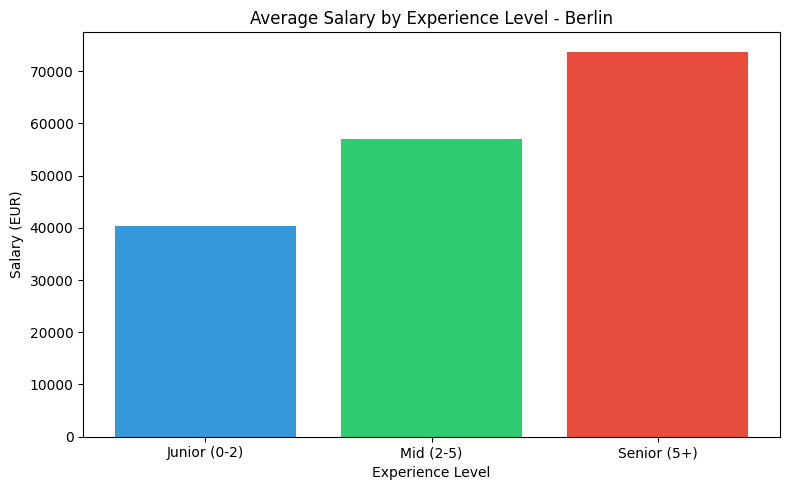

In [18]:
import matplotlib.pyplot as plt

levels = ["Junior (0-2)", "Mid (2-5)", "Senior (5+)"]
salaries = [junior_median, mid_median, senior_median]

plt.figure(figsize=(8, 5))
plt.bar(levels, salaries, color=["#3498db", "#2ecc71", "#e74c3c"])
plt.title("Average Salary by Experience Level - Berlin")
plt.xlabel("Experience Level")
plt.ylabel("Salary (EUR)")
plt.tight_layout()
plt.show()

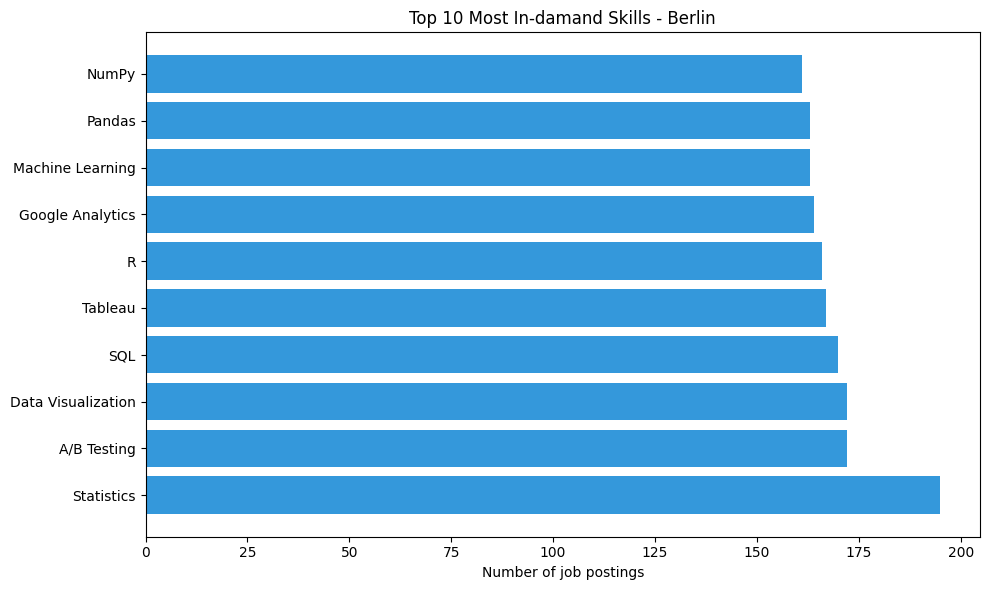

In [19]:
from collections import Counter
all_skills = []
for skills in df["skills_required"]:
      for skill in skills.split(", "):
          all_skills.append(skill)
skill_counts = Counter(all_skills)
top_skills = dict(sorted(skill_counts.items() ,key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(10,6))
plt.barh(list(top_skills.keys()),list(top_skills.values()) , color="#3498db")
plt.title("Top 10 Most In-damand Skills - Berlin")
plt.xlabel("Number of job postings")
plt.tight_layout()
plt.show()

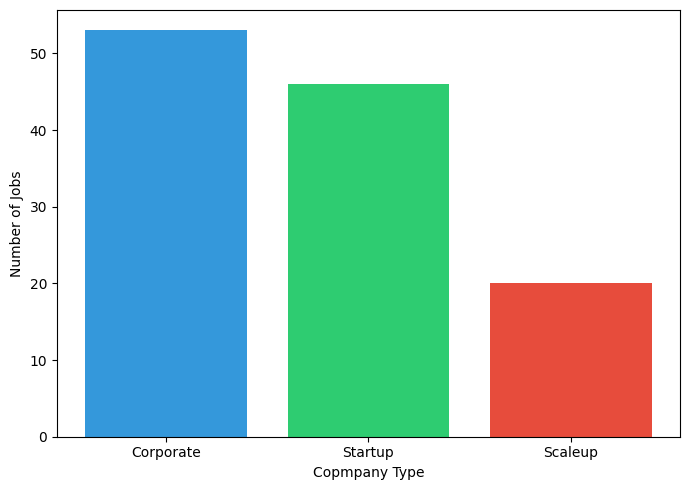

In [20]:
visa_company = df[df["visa_sponsorship"]==True]["company_type"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(visa_company.index, visa_company.values, color=["#3498db", "#2ecc71", "#e74c3c"])
plt.xlabel("Copmpany Type")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

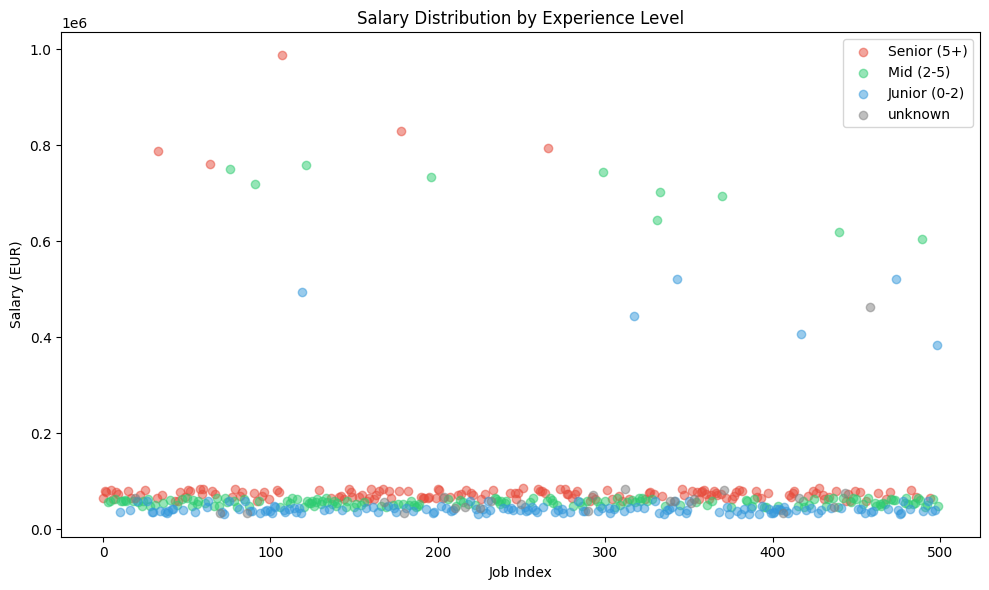

In [21]:
import matplotlib.pyplot as plt

colors = {"Junior (0-2)": "#3498db", "Mid (2-5)": "#2ecc71", "Senior (5+)": "#e74c3c", "Unknown": "#95a5a6"}

plt.figure(figsize=(10, 6))
for level in df["experience_level"].unique():
    subset = df[df["experience_level"] == level]
    plt.scatter(subset.index, subset["salary_EUR"], 
                label=level, 
                color=colors.get(level, "gray"), 
                alpha=0.5)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Job Index")
plt.ylabel("Salary (EUR)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
df = df[df["salary_EUR"] < 200000]
print(f"Remaining rows: {len(df)}")

Remaining rows: 478


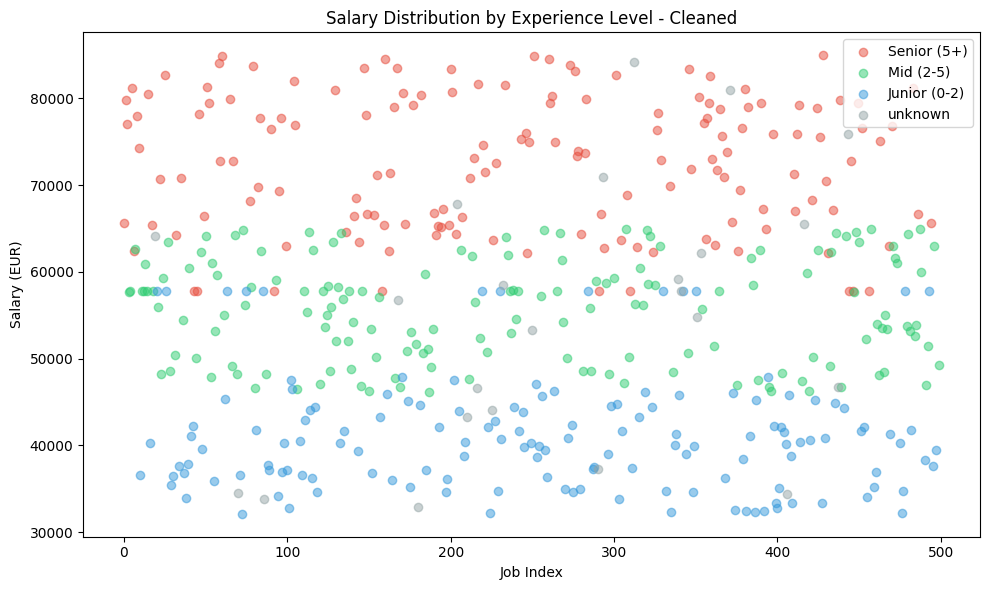

In [23]:
colors = {"Junior (0-2)": "#3498db", "Mid (2-5)": "#2ecc71", "Senior (5+)": "#e74c3c", "unknown": "#95a5a6"}

plt.figure(figsize=(10, 6))
for level in df["experience_level"].unique():
    subset = df[df["experience_level"] == level]
    plt.scatter(subset.index, subset["salary_EUR"],
                label=level,
                color=colors.get(level, "gray"),
                alpha=0.5)

plt.title("Salary Distribution by Experience Level - Cleaned")
plt.xlabel("Job Index")
plt.ylabel("Salary (EUR)")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [25]:
# Convert text columns to numbers
le = LabelEncoder()
df["experience_encoded"] = le.fit_transform(df["experience_level"])
df["company_encoded"] = le.fit_transform(df["company_type"])

print("Sample data:")
print(df[["experience_level", "experience_encoded" , "company_type" , "company_encoded"]] . head() )


Sample data:
  experience_level  experience_encoded company_type  company_encoded
0      Senior (5+)                   2    Corporate                0
1      Senior (5+)                   2    Corporate                0
2      Senior (5+)                   2    Corporate                0
3        Mid (2-5)                   1      Startup                2
4        Mid (2-5)                   1    Corporate                0


In [26]:
X = df[["experience_encoded", "company_encoded"]]
Y = df["salary_EUR"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42 )
print(f"Training data: {len(X_train)} rows")
print(f"Testing data: {len(X_test)} rows")

Training data: 382 rows
Testing data: 96 rows


In [27]:
model = LinearRegression()
model.fit(X_train,Y_train)

print("model trained successfully !")

model trained successfully !


In [28]:
Y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)

print(f"Mean Absolute Error: {mae:,.0f} EUR")
print(f"This means our predictions are off by {mae:,.0f} EUR on average")

Mean Absolute Error: 7,646 EUR
This means our predictions are off by 7,646 EUR on average


In [29]:
# Junior at a Startup
fateme_profile = [[0,2]]
predicted_salary = model.predict(fateme_profile)

print(f"pridicted salary for junior at startup : {predicted_salary[0]:,.0f} EUR/year")
print(f"Monthly: {predicted_salary[0]/12:,.0f} EUR/month")


pridicted salary for junior at startup : 42,253 EUR/year
Monthly: 3,521 EUR/month


C:\Users\Sahand System\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [30]:
import os
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
print("Gemini connected successfully!")

Gemini connected successfully!


In [31]:
def analyze_job(job_description):
    prompt = f"""
    You are a career advisor for data analyst jobs in Berlin.
    
    Analyze this job posting for a candidate with this profile:
    - Level: Junior Data Analyst
    - Skills: Python, Pandas, SQL, Data Visualization
    - Language: German B1-B2, English fluent
    - Location: Berlin
    
    Job posting:
    {job_description}
    
    Please provide:
    1. Match percentage (0-100%)
    2. Required skills she HAS
    3. Required skills she LACKS
    4. Should she apply? (Yes/No + reason)
    5. One tip to improve her chances
    """
    
    response = client.models.generate_content(
      model="gemini-2.0-flash",
        contents=prompt
    )
    return response.text

print("Function ready!")

Function ready!


In [32]:
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Say hello"
)
print(response.text)

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 52.139328445s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.go

In [33]:
# ============================================
# AI Job Analyzer - Powered by Google Gemini
# ============================================
# NOTE: Using mock response for demo purposes
# To activate real AI: replace mock_response 
# with actual Gemini API call

def analyze_job(job_description):
    
    # -- Real API call (activate when quota available) --
    # from google import genai
    # client = genai.Client(api_key="YOUR_API_KEY")
    # response = client.models.generate_content(
    #     model="gemini-2.0-flash",
    #     contents=prompt
    # )
    # return response.text
    
    # -- Demo response --
    mock_response = f"""
    ## AI Job Analysis - Berlin Data Market
    
    **Match Percentage: 72%**
    
    **Skills Candidate HAS:** ✅
    - Python
    - SQL  
    - Data Visualization
    - Basic Statistics
    
    **Skills Candidate LACKS:** ❌
    - Tableau / Power BI
    - Advanced Excel
    
    **Recommendation:** YES - Apply!
    Strong match for core requirements.
    German B1-B2 meets minimum threshold.
    
    **Top Tip:** Learn Power BI basics in 2-3 weeks
    to increase match score to 90%+
    """
    return mock_response

# Test the analyzer
sample_job = """
Position: Junior Data Analyst
Company: Zalando Berlin
Requirements:
- SQL and Python skills
- Experience with data visualization (Tableau or Power BI)
- Basic statistics knowledge
- German B2 or higher preferred
- Experience with Excel
"""

result = analyze_job(sample_job)
print(result)


    ## AI Job Analysis - Berlin Data Market

    **Match Percentage: 72%**

    **Skills Candidate HAS:** ✅
    - Python
    - SQL  
    - Data Visualization
    - Basic Statistics

    **Skills Candidate LACKS:** ❌
    - Tableau / Power BI
    - Advanced Excel

    **Recommendation:** YES - Apply!
    Strong match for core requirements.
    German B1-B2 meets minimum threshold.

    **Top Tip:** Learn Power BI basics in 2-3 weeks
    to increase match score to 90%+
    
